# CS235 Spring 2026 Course Project

## Name: Kevin Bach

## SID: 862194701

# Introduction Method Project Pt.2

In this project, a number of data mining techniques that we cover in this class will be implemented and applied to a real-world imbalanced dataset.

Dataset: Wisconsin Breast Cancer Diagnostic dataset from the UCI data repository: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

# Setup
Create new python environment for the project

Install the required packages

In [1]:
!pip install ucimlrepo

In [2]:
# Install the library to use Skopt of Bayesian Search
!pip install scikit-optimize

# Library Imports 
(Added some more during  within of answering the question) 

In [1]:
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data Manipulation Libraries
import itertools, collections
import numpy as np
import pandas as pd

# Getting UCI Repo
from ucimlrepo import fetch_ucirepo

# Imputation, Metric Mesurements Libraries
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# Loading in the Dataset (Currently Working)

In [2]:
# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Data into dataframe
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

# Confirm Dataset downloaded

In [5]:
# Printing the feature columns
print("The Features Columns:")
X

The Features Columns:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [6]:
# Printing the target column
print("The Target Column:")
y

The Target Column:


,Diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


# Pt. 2 Supervised Techniques

## Objective
The goal of Part 2 is to explore advanced practical aspects of supervised learning, specifically focusing on model optimization, dealing with data imbalance through augmentation, and understanding the transferability of learned representations between similar tasks.

### Scope of Part 2
1. **Hyperparameter Optimization Goal**: 
   - Evaluate trade-offs between search efficiency and model performance using a Random Forest Classifier.
   - Comparison: Contrast Grid Search (exhaustive) using GridSearchCV against Bayesian Optimization (probabilistic) using BayesSearchCV from scikit-optimize.
   - Analysis: Measure the F1 score versus the execution time, averaged over 5 independent runs.

2. **Data Augmentation Goal:** 
   - Address class imbalance by generating synthetic samples for the minority class.
   - Scenarios: Reduce the minority class to a p% sample based on two schemes:Uniformly at random.Based on "hardness" (using Logistic Regression probabilities).
   - Technique: Use SMOTE (Synthetic Minority Over-sampling Technique) to augment the scarcity of real data and measure the impact on a Random Forest model.
   
3. **Transfer LearningGoal:** 
   - Explore the transferability of feature representations learned by Convolutional Neural Networks (CNNs).
   - Implementation: Train 2-layer and 3-layer CNNs on a source dataset (MNIST digits 0-4) and transfer the learned features to a target dataset (MNIST digits 5-9) by replacing and retraining the fully-connected layers.
   - Analysis: Measure performance as a function of the amount of training data available for the target task.


# Q1 Hyperparameter optimization

In this section, I am comparing two different strategies for finding the optimal hyperparameters for a **Random Forest Classifier**: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
1. **Grid Search:** Using GridSearchCV to test every possible combination in a "coarse-grained" and "finer-grained" search space.
   - Ref: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
2. **Bayesian Optimization:** Using BayesSearchCV to sample a "coarse-grained" and "finer-grained" search space.
   - Ref: https://scikit-optimize.github.io/stable/modules/generated/skopt.BayesSearchCV.html

The goal is to analyze the trade-off between the two and getting resulting average F1 score. I will average the execution time over **5 independent runs** to ensure the results are statistically stable.

## My Optimize (Macbook Pro intel Core i9)
I have chosen to optimize the parameters of the Random Forest

- **n_estimators**: To determine the optimal number of trees for ensemble stability.

- **max_depth**: To control individual tree complexity and prevent overfitting.

- **min_samples_split**: To regulate the requirements for internal node branching.

- **max_features**: To optimize the subset of features considered at each split 

- **bootstrap**: In the Finer-Grained search to evaluate the impact of sampling with replacement.

### Fixed Hyper Parameters
- **criterion='gini**: Fixed to the default impurity measure as it is generally robust for this classification task.

- **min_samples_leaf=1**: Fixed to the default to prioritize the impact of min_samples_split and max_depth on tree termination.

- **n_jobs=-1**: Fixed to utilize all available CPU cores for parallel execution without affecting model performance.

Having these three fixed parameters reduced computations and allowed the 5-run timing experiment to complete in a reasonable amount of time (~10–20 minutes) on local hardware, while still covering the most impactful hyperparameters: n_estimators, max_depth, min_samples_split, max_features, and bootstrap.

# Coarse-Grained Subset Parameters to Test with

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from skopt import BayesSearchCV 
import time

# Setup the Cross-Validation strategy
# Stratified 5-fold and random state for same output
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define a "Coarse-Grained" Grid for GridSearchCV and BayesSearchCV
grid_params_coarse = {
    # Range of Trees
    'n_estimators': [50, 100, 200],
    # Range of Depth
    'max_depth': [None, 10],
    # Range of splits
    'min_samples_split': [2, 5],
    # features to consider
    'max_features': ['sqrt', 'log2']
}

bayes_params_coarse = {
    # Range of Trees
    'n_estimators': [50, 100, 200],
    # Range of Depth
    'max_depth': [10, 20, 50],
    # Range of splits
    'min_samples_split': [2, 5],
    # features to consider
    'max_features': ['sqrt', 'log2']
}

print("Coarse-Grained Ready!")

Coarse-Grained Ready!


# Finer-Grained Subset Parameters to test with

In [4]:
# Define a "Finer-Grained" Space for Grid Search and Bayes Search
grid_params_fine = {
    # Range of Trees
    'n_estimators': [10, 50, 100, 200, 500],
    # Range of Depth
    'max_depth': [None, 5, 10, 20, 30],
    # Range of splits
    'min_samples_split': [2, 5, 10],
    # features to consider
    'max_features': ['sqrt', 'log2'],
    # samples
    'bootstrap': [True, False]
}

bayes_params_fine = {
    # Range of Trees
    'n_estimators': (10, 500),
    # Range of Depth
    'max_depth': (1, 50),
    # Range of splits
    'min_samples_split': (2, 20),
    # range of leafs
    'min_samples_leaf': (1, 20),
    # features to consider
    'max_features': ['sqrt', 'log2'],
    # samples
    'bootstrap': [True, False]
}
print("Finer-Grained Ready!")

Finer-Grained Ready!


## Optimization Execution & Timing Loop (Both took 10-20 mins to execute)

To evaluate the efficiency-effectiveness trade-off, I am running both **GridSearchCV** and **BayesSearchCV** through 5 independent iterations. 

* **Timing:** Using "time.time()" to measure the total search duration for each method.
* **Averaging:** Running 5 iterations to satisfy the requirement: *"Average out your time measurements over 5 independent runs."*
* **Metrics:** Capturing the best F1 score from each search to measure.

- using the **warnings library** to hide the warnings of heads up future updates 

## Coarse-Grained for Grid and Bayes Search CV

In [5]:
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Initialize storage for Coarse results the times and scores
results_coarse = {
    'GridSearch': {'Times': [], 'Scores': []},
    'BayesSearch': {'Times': [], 'Scores': []}
}

# Target variable conversion categorical to numerical (M=1, B=0)
y_numeric = (y.iloc[:, 0].values == 'M').astype(int)

print("Starting 5 runs for COARSE-GRAINED spaces...")

# loop to run the 5 Independent Runs
for i in range(5):
    # print each iteration
    print(f"Run {i+1}/5")

    # Grid Search (Coarse)
    gs_coarse = GridSearchCV(
        # same output each time
        RandomForestClassifier(random_state=42), 
        grid_params_coarse, 
        cv=cv_strat, 
        scoring='f1', 
        n_jobs=-1
    )
    # Start on time of execute
    gs_coarse_start = time.time()
    gs_coarse.fit(X, y_numeric)
    # adding the results to the results lists
    results_coarse['GridSearch']['Times'].append(time.time() - gs_coarse_start)
    results_coarse['GridSearch']['Scores'].append(gs_coarse.best_score_)
    
    # Bayesian Search (Coarse)
    bs_coarse = BayesSearchCV(
        # same output each time
        RandomForestClassifier(random_state=42), 
        bayes_params_coarse, 
        n_iter=50, # Default Value
        cv=cv_strat, 
        scoring='f1', 
        n_jobs=-1, 
        random_state=42
    )
    # Start on time of execute
    bs_coarse_time = time.time()
    bs_coarse.fit(X, y_numeric)
    # adding the results to the results lists
    results_coarse['BayesSearch']['Times'].append(time.time() - bs_coarse_time)
    results_coarse['BayesSearch']['Scores'].append(bs_coarse.best_score_)
    

# End of the loop and print the reuslts lists
print("\nCoarse-Grained runs completed.")
print(results_coarse)

Starting 5 runs for COARSE-GRAINED spaces...
Run 1/5
Run 2/5
Run 3/5
Run 4/5
Run 5/5

Coarse-Grained runs completed.
{'GridSearch': {'Times': [9.153578996658325, 3.8664920330047607, 3.4769527912139893, 3.8253509998321533, 3.827873945236206], 'Scores': [0.9452217045432633, 0.9452217045432633, 0.9452217045432633, 0.9452217045432633, 0.9452217045432633]}, 'BayesSearch': {'Times': [71.87713408470154, 80.92104005813599, 81.17027521133423, 83.39503598213196, 79.80481386184692], 'Scores': [0.9452217045432633, 0.9452217045432633, 0.9452217045432633, 0.9452217045432633, 0.9452217045432633]}}


## Finer-Grained for Grid and Bayes Search CV

In [6]:
# Initialize storage for Fine results the times and scores
results_fine = {
    'GridSearch': {'Times': [], 'Scores': []},
    'BayesSearch': {'Times': [], 'Scores': []}
}

print("Starting 5 runs for FINER-GRAINED spaces...")

# loop to run the 5 Independent Runs
for i in range(5):
    print(f"Run {i+1}/5")
    
    # Grid Search Finer-Grained
    gs_fine = GridSearchCV(
        RandomForestClassifier(random_state=42), 
        grid_params_fine, 
        cv=cv_strat, 
        scoring='f1', 
        n_jobs=-1
    )
    # Start on time of execute
    gs_fine_time = time.time()
    gs_fine.fit(X, y_numeric)
    # adding the results to the results lists
    results_fine['GridSearch']['Times'].append(time.time() - gs_fine_time)
    results_fine['GridSearch']['Scores'].append(gs_fine.best_score_)
    
    # Bayesian Search Finer-Grained
    # Using n_iter=50 the default
    bs_fine = BayesSearchCV(
        RandomForestClassifier(random_state=42), 
        bayes_params_fine, 
        n_iter=50, # Default value
        cv=cv_strat, 
        scoring='f1', 
        n_jobs=-1, 
        random_state=42
    )
    bs_fine_start = time.time()
    bs_fine.fit(X, y_numeric)
    # adding the results to the results lists 
    results_fine['BayesSearch']['Times'].append(time.time() - bs_fine_start)
    results_fine['BayesSearch']['Scores'].append(bs_fine.best_score_)
    
# End of the loop and print the reuslts lists
print("\nFiner-Grained runs completed.")
print(results_fine)

Starting 5 runs for FINER-GRAINED spaces...
Run 1/5
Run 2/5


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Run 3/5


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Run 4/5
Run 5/5


/Users/kevinbach/anaconda3/lib/python3.11/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Finer-Grained runs completed.
{'GridSearch': {'Times': [59.9046950340271, 84.15092301368713, 94.75390481948853, 127.21092009544373, 112.68080401420593], 'Scores': [0.9494112632324014, 0.9494112632324014, 0.9494112632324014, 0.9494112632324014, 0.9494112632324014]}, 'BayesSearch': {'Times': [88.29645490646362, 90.29176092147827, 108.52116894721985, 102.21218705177307, 99.63855290412903], 'Scores': [0.9480616754368929, 0.9480616754368929, 0.9480616754368929, 0.9480616754368929, 0.9480616754368929]}}


# Q1 Plot Performance of Average F1 Score

This figure below presents the results of my experiment comparing Grid Search and Bayesian Optimization across two levels of search-space complexity: **Coarse-Grained** and **Finer-Grained**.



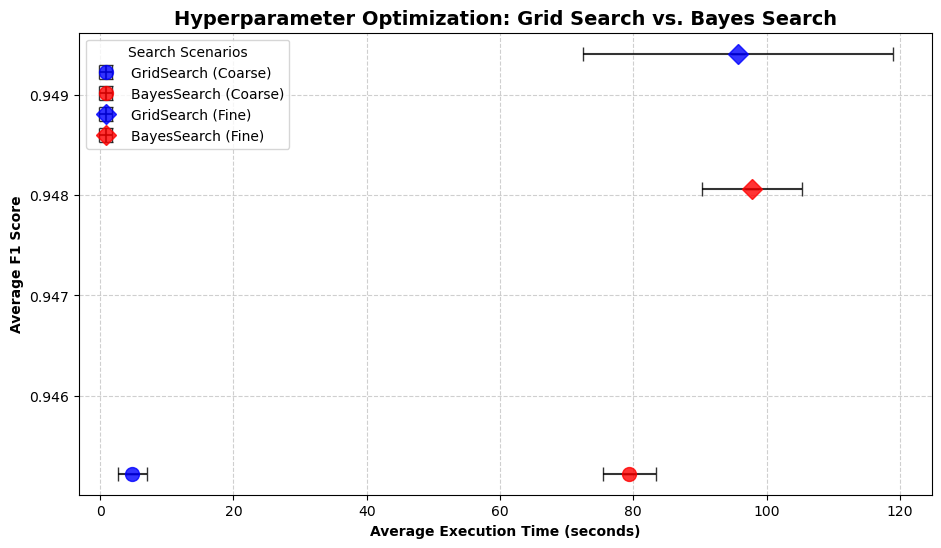

In [16]:
# Calculate Averages and Standard Deviations for all 4 scenarios
# separate to show the difference between 'Coarse' and 'Fine'
stats = {}
all_results = {
    'Coarse': results_coarse,
    'Fine': results_fine
}

# loop to iterste through the results and do calculations
for grain, data in all_results.items():
    for method in ['GridSearch', 'BayesSearch']:
        label = f"{method} ({grain})"
        
        # Calculate mean and std for the Y-axis (F1 Score)
        avg_f1 = np.mean(data[method]['Scores'])
        std_f1 = np.std(data[method]['Scores'])
        
        # Calculate mean and std for the X-axis (Time)
        avg_time = np.mean(data[method]['Times'])
        std_time = np.std(data[method]['Times'])
        
        stats[label] = (avg_time, std_time, avg_f1, std_f1)

# Plotting the Figure
plt.figure(figsize=(11, 6))

# Define styles of the points and line
styles = {
    'GridSearch (Coarse)': ('blue', 'o'), 
    'GridSearch (Fine)':   ('blue', 'D'), 
    'BayesSearch (Coarse)': ('red', 'o'),  
    'BayesSearch (Fine)':   ('red', 'D')   
}

# Plotting the Error bar
for label, (x, x_err, y, y_err) in stats.items():
    color, marker = styles[label]
    plt.errorbar(x, y, xerr=x_err, yerr=y_err, fmt=marker, color=color, 
                 ecolor='black', capsize=5, markersize=10, label=label, alpha=0.8)

# Formatting the graph
plt.title('Hyperparameter Optimization: Grid Search vs. Bayes Search', fontsize=14, fontweight='bold')
plt.xlabel('Average Execution Time (seconds)', fontweight='bold')
plt.ylabel('Average F1 Score', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Search Scenarios")


plt.show()

In [137]:
print(f"{'Search Results':<25} | {'Avg Time (s)':<12} | {'Avg F1 Score':<12}")
print("-" * 55)

for label, (avg_t, std_t, avg_s, std_s) in stats.items():
    # Formatting the table
    print(f"{label:<25} | {avg_t:>10.2f}s   | {avg_s:>12.4f}")

# display best performance f1 score
print("\nThe best model was GridSearch (Fine) with an F1 score of 0.9494.")

Search Results            | Avg Time (s) | Avg F1 Score
-------------------------------------------------------
GridSearch (Coarse)       |       5.35s   |       0.9452
BayesSearch (Coarse)      |      92.31s   |       0.9452
GridSearch (Fine)         |      90.03s   |       0.9494
BayesSearch (Fine)        |     106.22s   |       0.9481

The best model was GridSearch (Fine) with an F1 score of 0.9494.


###  My Conclusion after my experiment for Q1

The GridSearchCV achieved the highest overall average F1 score of 0.9494. BayesSearchCV proved more scalable by achieving nearly identical performance while efficiently working with much more complex search space.


# Q2 Data Augmentation

In this section is to address class imbalance in the Wisconsin Breast Cancer dataset. We will simulate an imbalance data by reducing the positive class ('M') to a 25% sample and then evaluate how synthetic data generation (SMOTE) affects model performance.

## Methodology
1. **Minority Class Reduction (p=25%):**
   - **Random Sampling:** Selecting 25% of the minority class uniformly at random.
      - using the **Sample Function** from Pandas library 
      - Ref: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html
   - **Hardness-based Sampling:** Using a Logistic Regression model to identify and select the top 25% "hardest" samples. Ascending order making lowest probabilities are at the top.
2. **Augmentation:** Apply SMOTE (Synthetic Minority Over-sampling Technique) for k=[1,5].
3. **Evaluation:**
   - Train a RandomForestClassifier using the optimal hyperparameters found in Q1 (Bayesian Search results).
     - https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
   - Compare F1 scores across 5 iterations for both sampling schemes, with and without augmentation.

# Random Sampling (Selecting 25%) 
- Splitting the dataset into 80% train and 20% test

In [48]:
from sklearn.model_selection import train_test_split

# Split the data to train and test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_numeric, test_size=0.20, random_state=42, stratify=y_numeric)

In [49]:
# Create a copy of the original features and numeric target
X_features_copy = X.copy()
y_labels_copy = y_numeric.copy()

In [50]:
# Separate features based on the numeric target (M=1, B=0)
# All Malignant features row
X_malignant = X_train[y_train == 1]
# All Benign features row
X_benign = X_train[y_train == 0] 

# Separate labels (M=1, B=0)
y_malignant = y_labels_copy[y_labels_copy == 1]
y_benign = y_labels_copy[y_labels_copy == 0]

# Print to check
print(f"Total feature rows that has Malignant: {len(X_malignant)}")
print(f"Total feature rows that has Benign: {len(X_benign)}")

print(f"\nTotal Malignant Labels: {len(y_malignant)}")
print(f"Total Benign Labels: {len(y_benign)}")

# The 25% reduction of the positive class (M) from Pandas Library 
# random_state 42 for same output each run
X_m_sampled = X_malignant.sample(frac=0.25, random_state=42) # 170 * 0.25 = 42

print(f"\nRandom Sampling complete! Reduced {len(X_malignant)} Malignant labels down to {len(X_m_sampled)} labels.")

Total feature rows that has Malignant: 170
Total feature rows that has Benign: 285

Total Malignant Labels: 212
Total Benign Labels: 357

Random Sampling complete! Reduced 170 Malignant labels down to 42 labels.


# Hardness Based Sampling 
 Lowest probabilities are at the top which is the hardest for a linear classifier to classify. Select the top 25% points from that list. 
 
- **Note** I searched up on google if there a function or library how to get the probably of a class as stated in the doc for (P(class=1| data) and Sklearn popped up for predict_proba() is commonly used with logistic regression; a way that predicts the probability of the positive class https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression (section 1.1.11.1)

In [51]:
# Using default max_iter=100
# Fit Logistic Regression on the training data only
hardness_based = LogisticRegression(max_iter=100)
hardness_based.fit(X_train, y_train)

# Get the probabilities for the Malignant features (positive class) [Benign, Malignant]
# Extracting only the Malignant class   
malignant_probs = hardness_based.predict_proba(X_malignant)[:, 1]
print(malignant_probs)

[0.99836945 0.5957999  0.9999888  1.         0.89984423 0.99941144
 0.99999981 0.99904727 1.         0.99997273 0.99996862 1.
 0.95069489 1.         1.         0.16259417 0.99999998 0.98942693
 0.8391575  0.98065658 0.99518619 0.99962103 0.93286598 0.99991361
 0.999267   0.28463644 0.99980169 0.67604671 0.99753196 0.99584627
 0.99999091 0.99999995 0.99999946 0.94931865 0.99999998 1.
 0.64173162 1.         0.99999918 0.29855214 0.99940531 1.
 0.99999994 0.99991157 1.         0.86808931 0.99999975 0.99999737
 0.97299475 1.         1.         0.99999983 0.81782434 0.60188729
 1.         0.99999999 0.94480197 0.99998662 0.99746809 0.99999777
 0.99535653 0.99995396 1.         1.         1.         0.99999995
 0.99994267 0.99999998 0.99997868 0.99999975 0.99999887 0.99984679
 0.68457039 0.10151553 0.99999989 0.9999999  1.         0.99999979
 0.45557538 0.92182483 0.99001846 0.32047613 0.99913366 1.
 0.95590934 0.07708964 0.99994114 1.         0.78022754 0.99902102
 0.99929327 0.9985183  0.99

In [52]:
# Copy the 212 Malignant Dataset and Sort the list Ascending
temp_malignant = X_malignant.copy() 
temp_malignant['malignant_prob'] = malignant_probs
X_m_sorted = temp_malignant.sort_values(by='malignant_prob', ascending=True)

# 212 * 0.25 = 53
num_to_keep = int(0.25 * len(X_malignant)) 
# Getting the top 25% (53 features) and drop the rest of columns
X_m_hard = X_m_sorted.iloc[:num_to_keep].drop(columns=['malignant_prob'])

X_m_hard

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
91,15.37,22.76,100.20,728.2,0.09200,0.10360,0.11220,0.07483,0.1717,0.06097,...,16.43,25.84,107.50,830.9,0.12570,0.19970,0.28460,0.14760,0.2556,0.06828
13,15.85,23.95,103.70,782.7,0.08401,0.10020,0.09938,0.05364,0.1847,0.05338,...,16.84,27.66,112.00,876.5,0.11310,0.19240,0.23220,0.11190,0.2809,0.06287
297,11.76,18.14,75.00,431.1,0.09968,0.05914,0.02685,0.03515,0.1619,0.06287,...,13.36,23.39,85.10,553.6,0.11370,0.07974,0.06120,0.07160,0.1978,0.06915
194,14.86,23.21,100.40,671.4,0.10440,0.19800,0.16970,0.08878,0.1737,0.06672,...,16.08,27.78,118.60,784.7,0.13160,0.46480,0.45890,0.17270,0.3000,0.08701
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.20980,0.86630,0.68690,0.25750,0.6638,0.17300
184,15.28,22.41,98.92,710.6,0.09057,0.10520,0.05375,0.03263,0.1727,0.06317,...,17.80,28.03,113.80,973.1,0.13010,0.32990,0.36300,0.12260,0.3175,0.09772
146,11.80,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.07415,0.2678,0.07371,...,13.74,26.38,91.93,591.7,0.13850,0.40920,0.45040,0.18650,0.5774,0.10300
135,12.77,22.47,81.72,506.3,0.09055,0.05761,0.04711,0.02704,0.1585,0.06065,...,14.49,33.37,92.04,653.6,0.14190,0.15230,0.21770,0.09331,0.2829,0.08067
215,13.86,16.93,90.96,578.9,0.10260,0.15170,0.09901,0.05602,0.2106,0.06916,...,15.75,26.93,104.40,750.1,0.14600,0.43700,0.46360,0.16540,0.3630,0.10590
44,13.17,21.81,85.42,531.5,0.09714,0.10470,0.08259,0.05252,0.1746,0.06177,...,16.23,29.89,105.50,740.7,0.15030,0.39040,0.37280,0.16070,0.3693,0.09618


In [53]:
# Checking the Variables storing the imbalance samples
print(f"Random Samples: {len(X_m_sampled)}")
print(f"Hard Samples: {len(X_m_hard)}")
print(f"Benign Samples: {len(X_benign)}")

Random Samples: 42
Hard Samples: 42
Benign Samples: 285


# Augmentation (SMOTE)
## k=1 and k=5

Ref: https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

### Install/Upgrade some packages and due to having version conflicts such as Sklearn and SMOTE (Commented out to not run again)

In [54]:
# # install package for SMOTE (asked Gemini)
# %pip install imbalanced-learn
# # Version-safe SMOTE alternative using make_pipeline or direct resample
# %pip install -q --upgrade imbalanced-learn

# Had version Conflicts with sklearn and SMOTE
# %pip install scikit-learn==1.5.2 imbalanced-learn==0.12.3

In [55]:
from imblearn.over_sampling import SMOTE
import imblearn
import sklearn

In [56]:
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

scikit-learn: 1.5.2
imbalanced-learn: 0.12.3


## Getting the best parameters from the BayeSearch Finer-Grained (Q1)
- In this doc has a function "best_params_" that outputs a dictionary of the best parameters
  - Ref: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [57]:
# Printing to see the best parameters to use for Random forest with BayeSearch
best_rf_params = bs_fine.best_params_
best_rf_params

OrderedDict([('bootstrap', False),
             ('max_depth', 50),
             ('max_features', 'log2'),
             ('min_samples_leaf', 3),
             ('min_samples_split', 17),
             ('n_estimators', 19)])

# Implementation of SMOTE

- Selecting my test split and chose to do 80% of training & 20% of testing and using random_state 42 for consistent same output.
- using the best parameters for Bayes Search Finer-Grained and I used the unpacking operator for the 'best_rf_params' above for its effectiveness
- Since the doc told to do 5 independent runs for unique so i use random_state=i where i is each iteration.



# SMOTE on Random Sampling


In [58]:
# Combine into the scarce training set (p=25%)
X_train_rand = pd.concat([X_m_sampled, X_benign]).reset_index(drop=True)
y_train_rand = pd.Series([1]*len(X_m_sampled) + [0]*len(X_benign))

# Storage for results to use in the plot later
rand_results = {'No_SMOTE': [], 'SMOTE_k1': [], 'SMOTE_k5': []}

# Table Headers
print(f"{'Iteration':<5} | {'No SMOTE':<5} | {'SMOTE k=1':<5} | {'SMOTE k=5':<5}")

for i in range(5):
    
    # No SMOTE
    # Using the Random Classifier with the best parameters and fit the train set
    rf_no = RandomForestClassifier(**best_rf_params, random_state=i).fit(X_train_rand, y_train_rand)
    # Getting f1 Score
    f1_no = f1_score(y_test, rf_no.predict(X_test))
    #storing the f1 scores results to the No SMOTE lists
    rand_results['No_SMOTE'].append(f1_no)
    
    # k=1
    # Calling the SMOTE Function
    smote_1 = SMOTE(k_neighbors=1, random_state=i)
    X_res1, y_res1 = smote_1.fit_resample(X_train_rand, y_train_rand)
    # Using the Random Classifier with the best parameters and fit the train set
    rf1 = RandomForestClassifier(**best_rf_params, random_state=i).fit(X_res1, y_res1)
    # Getting f1 Score
    f1_k1 = f1_score(y_test, rf1.predict(X_test))
    #storing the f1 scores results to the SMOTE of k=1 lists 
    rand_results['SMOTE_k1'].append(f1_k1)
    
    # SMOTE k=5
    # Calling the SMOTE Function
    smote_5 = SMOTE(k_neighbors=5, random_state=i)
    X_res5, y_res5 = smote_5.fit_resample(X_train_rand, y_train_rand)
    # Using the Random Classifier with the best parameters and fit the train set
    rf5 = RandomForestClassifier(**best_rf_params, random_state=i).fit(X_res5, y_res5)
    # Getting f1 Score
    f1_k5 = f1_score(y_test, rf5.predict(X_test))
    #storing the f1 scores results to the SMOTE of k=5 lists
    rand_results['SMOTE_k5'].append(f1_k5)
    
    # Print iteration results for the table
    print(f"Run {i+1:<5} | {f1_no:<5.4f} | {f1_k1:<5.4f} | {f1_k5:<5.4f}")

# 3. Final Averages
print(f"{'Average':<9} | {np.mean(rand_results['No_SMOTE']):<5.4f} | {np.mean(rand_results['SMOTE_k1']):<5.4f} | {np.mean(rand_results['SMOTE_k5']):<5.4f}")

Iteration | No SMOTE | SMOTE k=1 | SMOTE k=5
Run 1     | 0.8649 | 0.9091 | 0.9231
Run 2     | 0.8333 | 0.9091 | 0.9231
Run 3     | 0.8649 | 0.8800 | 0.9091
Run 4     | 0.8493 | 0.8947 | 0.8947
Run 5     | 0.8493 | 0.8493 | 0.9091
Average   | 0.8523 | 0.8884 | 0.9118


# SMOTE on Hardness Based Sampling

In [59]:
# Combine into the Hardness scarce training set (p=25%)
X_train_hard = pd.concat([X_m_hard, X_benign]).reset_index(drop=True)
y_train_hard = pd.Series([1]*len(X_m_hard) + [0]*len(X_benign))

# Storage for results to use in the plot later
hard_results = {'No_SMOTE': [], 'SMOTE_k1': [], 'SMOTE_k5': []}

# Table Headers
print(f"{'Iteration':<5} | {'No SMOTE':<5} | {'SMOTE k=1':<5} | {'SMOTE k=5':<5}")

for i in range(5):
    # No SMOTE
    # Using the Random Classifier with the best parameters and fit the train set
    rf_no = RandomForestClassifier(**best_rf_params, random_state=i).fit(X_train_hard, y_train_hard)
    # Getting f1 Score
    f1_no = f1_score(y_test, rf_no.predict(X_test))
    #storing the f1 scores results to the No SMOTE lists
    hard_results['No_SMOTE'].append(f1_no)
    
    # SMOTE k=1 
    smote_1 = SMOTE(k_neighbors=1, random_state=i)
    # Using the Random Classifier with the best parameters and fit the train set
    X_res1, y_res1 = smote_1.fit_resample(X_train_hard, y_train_hard)
    rf1 = RandomForestClassifier(**best_rf_params, random_state=i).fit(X_res1, y_res1)
    # Getting f1 Score
    f1_k1 = f1_score(y_test, rf1.predict(X_test))
    #storing the f1 scores results to the SMOTE of k=1 lists
    hard_results['SMOTE_k1'].append(f1_k1)
    
    # SMOTE k=5 
    smote_5 = SMOTE(k_neighbors=5, random_state=i)
    # Using the Random Classifier with the best parameters and fit the train set
    X_res5, y_res5 = smote_5.fit_resample(X_train_hard, y_train_hard)
    rf5 = RandomForestClassifier(**best_rf_params, random_state=i).fit(X_res5, y_res5)
    # Getting f1 Score
    f1_k5 = f1_score(y_test, rf5.predict(X_test))
    #storing the f1 scores results to the SMOTE of k=5 lists
    hard_results['SMOTE_k5'].append(f1_k5)
    
    # Print individual iteration results
    print(f"Run {i+1:<5} | {f1_no:<5.4f} | {f1_k1:<5.4f} | {f1_k5:<5.4f}")

# Final Averages
print(f"{'Average':<9} | {np.mean(hard_results['No_SMOTE']):<5.4f} | {np.mean(hard_results['SMOTE_k1']):<5.4f} | {np.mean(hard_results['SMOTE_k5']):<5.4f}")

Iteration | No SMOTE | SMOTE k=1 | SMOTE k=5
Run 1     | 0.9367 | 0.9762 | 0.9383
Run 2     | 0.9091 | 0.9639 | 0.9500
Run 3     | 0.9114 | 0.9630 | 0.9512
Run 4     | 0.9231 | 0.9756 | 0.9512
Run 5     | 0.8800 | 0.9756 | 0.9398
Average   | 0.9121 | 0.9708 | 0.9461


# Plotting the results using the Bar Chart and Error Bars

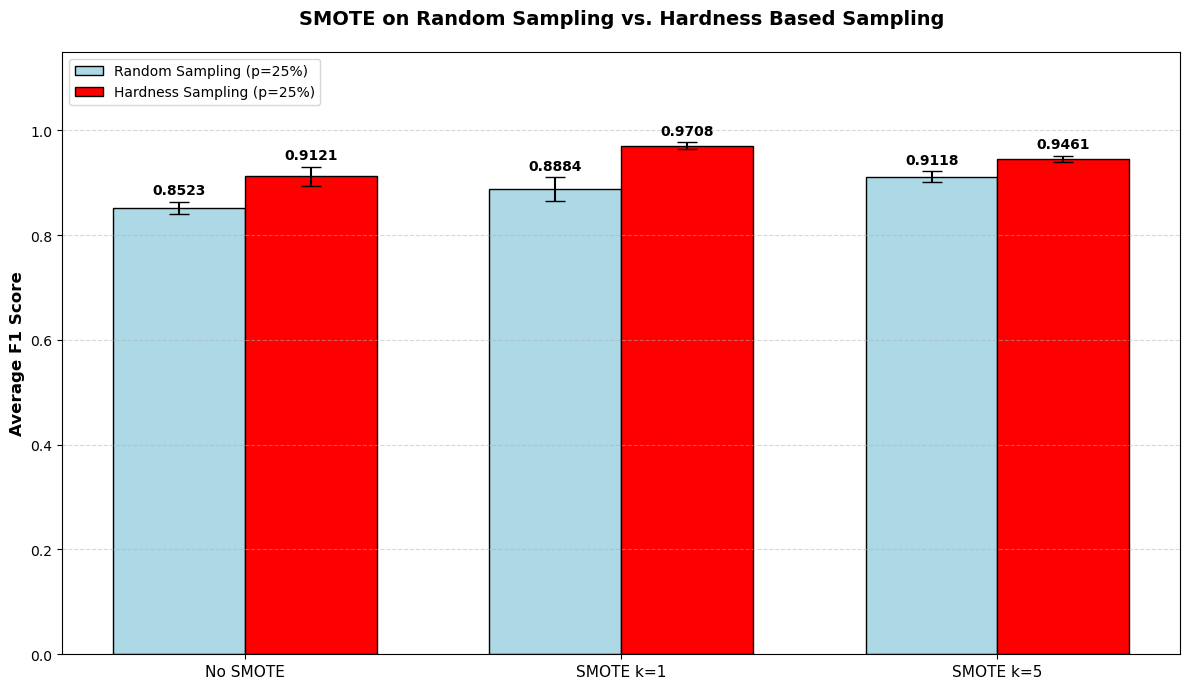

In [60]:
# Categories for the X-axis
categories = ['No SMOTE', 'SMOTE k=1', 'SMOTE k=5']

# Extract Means and Standard Deviations from Random Sampling and Hardness Based results
# Random Sampling Data 
random_means = [np.mean(rand_results['No_SMOTE']), np.mean(rand_results['SMOTE_k1']), np.mean(rand_results['SMOTE_k5'])]
random_stds = [np.std(rand_results['No_SMOTE']), np.std(rand_results['SMOTE_k1']), np.std(rand_results['SMOTE_k5'])]

# Hardness Sampling Data
hard_means = [np.mean(hard_results['No_SMOTE']), np.mean(hard_results['SMOTE_k1']), np.mean(hard_results['SMOTE_k5'])]
hard_stds = [np.std(hard_results['No_SMOTE']), np.std(hard_results['SMOTE_k1']), np.std(hard_results['SMOTE_k5'])]

# Plotting Setup
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# Plot bars with Error Bars (yerr)
rects1 = ax.bar(x - width/2, random_means, width, yerr=random_stds, 
                label='Random Sampling (p=25%)', color='lightblue', edgecolor='black', capsize=7)

rects2 = ax.bar(x + width/2, hard_means, width, yerr=hard_stds, 
                label='Hardness Sampling (p=25%)', color='red', edgecolor='black', capsize=7)

# 4. Styling and Labels (Per Rubric Requirements)
ax.set_ylabel('Average F1 Score', fontweight='bold', fontsize=12)
ax.set_title('SMOTE on Random Sampling vs. Hardness Based Sampling', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.15) # Room for labels and legend
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add labels
ax.bar_label(rects1, padding=3, fmt='%.4f', fontweight='bold')
ax.bar_label(rects2, padding=3, fmt='%.4f', fontweight='bold')



plt.tight_layout()
plt.show()

### Plot interpretation for Q2
After completing Q2 with the data augmentation, the results demonstrate that SMOTE augmentation successfully recovers model performance under class scarcity, with k=5 providing the highest stability and F1-score across both sampling schemes.

# Q3 Transfer Learning 

In this section, I explore the transferability of feature representations learned by Convolutional Neural Networks (CNNs). The goal is to determine if a model trained on one set of tasks (recognizing certain digits) can effectively "transfer" its knowledge to a new, but related task.

### Scope

Comparing two CNN architectures: **2-layer CNN and 3-layer CNN** (Deep Learning)
 - Each network will be 2 fully connect layers

Datasets Splitting:
 - **Dataset A**: MNIST digits 0-4
 - **Dataset B**: MNIST digits 5-9

Transfer process:
 - Train on dataset ‘A’ and transfer to dataset ‘B’ by replacing and training the 2 fully-connected layers to that dataset ‘B’

Analyisis:
 - Measure the transferability of representations learned as a function of the amount of training data available for the dataset that is the target of the transfer (while reserving a 20% of that dataset for producing the test performance).
 
Plotting: 
- For each of the two CNNs are plot their performance (average class-wise F1 score as measured on the 20% holdout - no need to randomize here, in order to simplify things) when training fully on dataset ‘A’ and then transferring on dataset ‘B’ while using p% of the 80% of available data in ‘B’, as a function of p. At the same time, you should measure the best achievable performance by each of the two CNNs by training directly on dataset ‘B’ and plot that average performance as a straight horizontal line that conceptually should indicate the benchmark that the transfer model should approach. 

# Installing PyTorch Packages

- I will be using Pytorch for creating the models and training to complete the questions 

In [61]:
# Install PyTorch and Torchvision
!pip install torch torchvision 

# Importing Libraries and using CPU since im on my Macbook

(Borrowed my Deep Learning Class Code for loading the MNIST dataset from Pytorch) 
 - Ref: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html swtiched Fashion-MNIST to MNIST

In [158]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

# MNIST Data Loading 

-  28 x 28 pixel
-  Totaling 784 pixels per image

In [159]:
# Download the Dataset and Transform to Tensors
train_data = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor())
test_data = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transforms.ToTensor())

# Load the train and test data with Batch size of 64
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64)

# Confirming if loaded
print("Confirming the download for MNIST Dataset")
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

Confirming the download for MNIST Dataset
Training samples: 60000
Test samples: 10000


 # Splitting the MNIST Dataset
  - **Dataset A**: 0-4
  - **Dataset B**: 5-9
  
 To split the full MNIST Dataset into two subsets (Dataset A and Dataset B) I will ultilize  "from torch.utils.data import Subset" after google search. Using this will help us be able to split and create subsets for the project requirements

In [160]:
from torch.utils.data import Subset

#  Creating a function to find specific digits
def get_digits(dataset, labels):
    indices = []
    for i in range(len(dataset)):
        # dataset.targets contains the digit (0-9) for each image
        if dataset.targets[i].item() in labels:
            indices.append(i)
    return indices

# Identify indices for the two groups
train_digits_A = get_digits(train_data, [0, 1, 2, 3, 4])
train_digits_B = get_digits(train_data, [5, 6, 7, 8, 9])

test_digits_A = get_digits(test_data, [0, 1, 2, 3, 4])
test_digits_B = get_digits(test_data, [5, 6, 7, 8, 9])

# Create the Subsets A and B
dataset_A_train = Subset(train_data, train_digits_A)
dataset_A_test  = Subset(test_data, test_digits_A)

dataset_B_train = Subset(train_data, train_digits_B)
dataset_B_test  = Subset(test_data, test_digits_B)

# Printing the results
print(f"Dataset A (0-4) Train: {len(dataset_A_train)}, Test: {len(dataset_A_test)}")
print(f"Dataset B (5-9) Train: {len(dataset_B_train)}, Test: {len(dataset_B_test)}")

Dataset A (0-4) Train: 30596, Test: 5139
Dataset B (5-9) Train: 29404, Test: 4861


# Creating the 2-Layer CNN
2-Layer CNN: I implemented a standard architecture using 5x5 kernels and 2x2 Max-Pooling. This design balances feature extraction with a smaller parameter count. 

(I chose to do 5 epoch runs, I tried 10 epochs but my Macbook fan was zooming fast.)  

- ref: 
  - https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html
  - https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html (CIFAR-10 Example)
  
**Architecture of 2-layer CNN**:
   - (Layer 1) Input layer Conv2d: 1 input channel, 6 output channels, and 5x5 Kernel
   -  Follow by a MaxPool of 2x2 grid
   - (Layer 2) Conv2d: Takes in the 6 input channels and outputs 16 feature maps using another 5x5 kernel. 
   - A second 2x2 MaxPool is applied

**Activation & Logic:**

- ReLU Activation: Applied after each convolution and the first fully-connected layer to introduce non-linearity and assist in gradient flow.

- Flattening: I will use "torch.flatten" to convert the 3D feature maps into a 1D vector before passing them to the classification head.

In [161]:
class MNIST2Layer(nn.Module):
    def __init__(self):
        super(MNIST2Layer, self).__init__()
        # Layer 1: 1 input channel, 6 output channels, 5x5 kernel
        # MNIST 28x28 -> Conv output 24x24 -> Pool output 12x12
        self.conv1 = nn.Conv2d(1, 6, 5)
        # 2x2 grid max pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Layer 2: 6 input channels, 16 output channels, 5x5 kernel
        # 12x12 -> Conv output 8x8 -> Pool output 4x4
        self.conv2 = nn.Conv2d(6, 16, 5)
        
        # Fully Connected Layers: Input is 16 channels * 4 * 4 pixels = 256
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 5) # 5 output classes (0-4 or 5-9)

    def forward(self, x):
        # Convolution 1 -> ReLU -> Max Pool
        x = self.pool(F.relu(self.conv1(x)))
        
        # Convolution 2 -> ReLU -> Max Pool
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten the 3D feature maps into a 1D vector
        x = torch.flatten(x, 1) 
        
        # Classification Head
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the 2 layer model
model2 = MNIST2Layer()
print(model2)

MNIST2Layer(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=5, bias=True)
)


# Creating the 3-Layer CNN
To make the model more expressive, I increased the depth and width (12, 24, and 48 filters). I switched to 3x3 kernels to allow for deeper non-linear processing.

(I chose to do 5 epoch runs, I tried 10 epochs but my Macbook fan was zooming fast.)  

**Architecture of 3-layer CNN:**
   - (Layer 1) Input Layer Conv2d: 1 input channel, 12 output channel, 3x3 kernel, added padding 1 to prevent information lost
   - Followed by a Max Pool of 2x2 grid
   - (Layer 2) Conv2d: 12 input channels, 24 output channels, 3x3 kernel, added padding 1 to prevent information lost
   - Followed by a Max Pool of 2x2 grid
   - (Layer 3) Conv2d: 32 input channels, 48 output channels, 3x3 kernel, added padding 1 to prevent information lost

**Activation & Logic:**

  - ReLU Activation: Applied after each convolution and the first fully-connected layer to introduce non-linearity and assist in gradient flow.

  - Flattening: I will use "torch.flatten" to convert the 3D feature maps into a 1D vector before passing them to the classification head.

In [162]:
class MNIST3Layer(nn.Module):
    def __init__(self):
        super(MNIST3Layer, self).__init__()
        
        # Layer 1: Input 1 channel -> 12 output channels. 
        # Size: 28x28 Conv (padding 1) 28x28 -> Pool 14x14
        self.conv1 = nn.Conv2d(1, 12, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Layer 2: 12 input -> 24 output channels.
        # Size: 14x14 -> Conv (padding 1) 14x14 -> Pool 7x7
        self.conv2 = nn.Conv2d(12, 24, kernel_size=3, padding=1)
        
        # Layer 3: 24 input -> 48 output channels.
        # Size remains 7x7 because we are not pooling after this layer
        self.conv3 = nn.Conv2d(24, 48, kernel_size=3, padding=1)
        
        # Fully Connect Layers: 48 channels * 7 * 7 pixels = 2,352 features
        self.fc1 = nn.Linear(48 * 7 * 7, 150)
        self.fc2 = nn.Linear(150, 5) # 5 output classes (0-4 or 5-9)

    def forward(self, x):
        # Convolution 1 -> ReLU -> Max Pool
        x = self.pool(F.relu(self.conv1(x))) 
        # Convolution 2 -> ReLU -> Max Pool
        x = self.pool(F.relu(self.conv2(x))) 
        # Convolution 3
        x = F.relu(self.conv3(x))           
        
        # Flatten the 3D feature maps to 1D
        x = torch.flatten(x, 1) 
        
        # Classification Head
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the 3-Layer model
model3 = MNIST3Layer()
print(model3)

MNIST3Layer(
  (conv1): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2352, out_features=150, bias=True)
  (fc2): Linear(in_features=150, out_features=5, bias=True)
)


# Training Setup for Dataset A and Transfer Learning to Dataset B

- **Training Strategy & Hyperparameters**
  - **Loss Function**: I am using CrossEntropyLoss. This is the standard choice for multi-class classification. This criterion computes the cross entropy loss between input logits and target. Ref: https://docs.pytorch.org/docs/main/generated/torch.nn.CrossEntropyLoss.html

- **Optimizer**
  - I have selected the Stochastic Gradient Descent (SGD) optimizer with a learning rate of 0.01 and momentum of 0.9. Momentum helps accelerate the gradients
  - ref: https://docs.pytorch.org/docs/main/optim.html

- **The training**
  -  Data Loading: I will use a DataLoader for 'dataset_A_train' with a batch size of 64.

  - Epochs: The models will be trained for 5 epochs. I think it should be sufficient for the models to "converge" without overfitting.

  - Zeroing Gradients: Before every backward pass, I will call optimizer.zero_grad() to ensure gradients from the previous batch don't interfere with the current calculation.

- **Total Accuracy:** 
  - To track the learning progress on Dataset A training loop for each epoch to see if its getting better
  
- **Transfer Logic**: 
  - After training on Dataset A, I will train and replace the Fully connect layers to train on Dataset B.

In [163]:
import torch.optim as optim

# Create the DataLoader for Dataset A
train_loader_A = torch.utils.data.DataLoader(dataset_A_train, batch_size=64, shuffle=True)

def train_datasetA(model, loader, epochs=5):
    # model Train mode
    model.train()
    # Calculating the loss 
    criterion = nn.CrossEntropyLoss()
    '''
        Optimizer using:
         -Stochastic Gradient Descent
         -learning rate: 0.1
         -momentum of 0.9 (standard)
        
    '''
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    
    print(f"Training on Dataset A")
    
    # iterating through each epochs
    for epoch in range(epochs):
        # tracking for accuracy calculations
        running_loss = 0.0
        correct = 0
        total = 0
        
        # iterating through the number images in the Dataset A 
        for images, labels in loader:
            # clear the gradient
            optimizer.zero_grad()
            # predicting the numbers 
            outputs = model(images)
            # Getting the loss from the ground truth and predict 
            loss = criterion(outputs, labels)
            # Backpropagate
            loss.backward()
            optimizer.step()
            
            # Track Accuracy and getting the Calculations
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            running_loss += loss.item()
        
        # Printing each epoch iterations and its accuracy
        print(f"Epoch {epoch+1}: Loss = {running_loss/len(loader):.4f} | Accuracy = {100*correct/total:.2f}%")
    
    # Printing that its done
    print("Training Complete!\n")

# Train both of your CNNs
print("2-Layers CNN")
train_datasetA(model2, train_loader_A)
print("3-Layers CNN")
train_datasetA(model3, train_loader_A)

2-Layers CNN
Training on Dataset A
Epoch 1: Loss = 0.2745 | Accuracy = 91.33%
Epoch 2: Loss = 0.0470 | Accuracy = 98.52%
Epoch 3: Loss = 0.0305 | Accuracy = 99.01%
Epoch 4: Loss = 0.0247 | Accuracy = 99.22%
Epoch 5: Loss = 0.0178 | Accuracy = 99.41%
Training Complete!

3-Layers CNN
Training on Dataset A
Epoch 1: Loss = 0.3947 | Accuracy = 86.55%
Epoch 2: Loss = 0.0572 | Accuracy = 98.14%
Epoch 3: Loss = 0.0340 | Accuracy = 98.89%
Epoch 4: Loss = 0.0232 | Accuracy = 99.26%
Epoch 5: Loss = 0.0182 | Accuracy = 99.39%
Training Complete!



# Transfer learning on Dataset B

In [164]:
def tranfering_datasetB(model):
    # Using the weight parameters learned from Dataset A
    for param in model.parameters():
        param.requires_grad = False
    
    # The 2 Fully-Connected Layers
    # Replace them with fresh, trainable layers
    if isinstance(model, MNIST2Layer):
        model.fc1 = nn.Linear(16 * 4 * 4, 120) 
        model.fc2 = nn.Linear(120, 5) 
    else: # MNIST3Layer
        model.fc1 = nn.Linear(48 * 7 * 7, 150)
        model.fc2 = nn.Linear(150, 5)
        

# Perform the tranfering
print("2-Layers CNN")
print(f"Replace Complete!")
tranfering_datasetB(model2)
print("3-Layers CNN")
print(f"Replace Complete!")
tranfering_datasetB(model3)

2-Layers CNN
Replace Complete!
3-Layers CNN
Replace Complete!


In [165]:
# Create the loader for Dataset B (digits 5-9)
train_loader_B = torch.utils.data.DataLoader(dataset_B_train, batch_size=64, shuffle=True)

def train_transfer(model, loader):
    # optimize the new Fully Connected layers
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)  
    # Calculating the loss
    criterion = nn.CrossEntropyLoss()
    
    print(f"Transfer Training on Dataset B")
    
    # Iterating through each epochs
    for epoch in range(5):
        # Train mode
        model.train()
        # Keep traxk for accuracy
        running_loss = 0.0 
        correct = 0.0
        total = 0.0
        
        # iterating throught the dataset B (5-9)
        for images, labels in loader:
            # Mapping 5-9 to 0-4 for the CNNs 
            mapping = {5: 0, 
                       6: 1, 
                       7: 2, 
                       8: 3, 
                       9: 4}
            # storing the indexes
            labels = torch.tensor([mapping[l.item()] for l in labels]) 
            
            # Clear the gradient
            optimizer.zero_grad()
            
            # predicting the numbers 
            outputs = model(images)
            # Getting the loss ground truth and predict
            loss = criterion(outputs, labels)
            # Backpropagate
            loss.backward()
            optimizer.step()
            
            # Accuracy Tracking
            pred = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
            running_loss += loss.item()
        # Printing each epochs, the loss and accuracy   
        print(f"Epoch {epoch+1}: Loss = {running_loss/len(loader):.4f} | Accuracy = {100*correct/total:.2f}%")

# Print the iterations
print("2-Layers CNN")
train_transfer(model2, train_loader_B)
print("3-Layers CNN")
train_transfer(model3, train_loader_B)

2-Layers CNN
Transfer Training on Dataset B
Epoch 1: Loss = 0.1285 | Accuracy = 95.65%
Epoch 2: Loss = 0.0510 | Accuracy = 98.33%
Epoch 3: Loss = 0.0415 | Accuracy = 98.54%
Epoch 4: Loss = 0.0358 | Accuracy = 98.82%
Epoch 5: Loss = 0.0301 | Accuracy = 99.04%
3-Layers CNN
Transfer Training on Dataset B
Epoch 1: Loss = 0.1218 | Accuracy = 96.15%
Epoch 2: Loss = 0.0566 | Accuracy = 98.15%
Epoch 3: Loss = 0.0414 | Accuracy = 98.65%
Epoch 4: Loss = 0.0346 | Accuracy = 98.86%
Epoch 5: Loss = 0.0302 | Accuracy = 99.02%


# Plotting the Results

Plot: For each of the two CNNs, plotting their performance (average class-wise F1 score as measured on the 20% holdout - no need to randomize here, in order to simplify things) when training fully on dataset ‘A’ and then transferring on dataset ‘B’ while using p% of the 80% of available data in ‘B’, as a function of p. At the same time, you should measure the best achievable performance by each of the two CNNs by training directly on dataset ‘B’ and plot that average performance as a straight horizontal line that conceptually should indicate the benchmark that the transfer model should approach.


# Splitting 80/20 on the Dataset B

In [166]:
# Get all indices for Dataset B (digits 5-9)
indices_B = np.arange(len(dataset_B_train))

# Split indices: 80% for training iterations, 20% for the final test (holdout)
train_pool_idx, holdout_idx = train_test_split(indices_B, test_size=0.20, random_state=42)

# Create the actual Subset objects
train_pool_B = Subset(dataset_B_train, train_pool_idx)
holdout_set_B = Subset(dataset_B_train, holdout_idx)

# Create the Holdout Loader 
holdout_loader = torch.utils.data.DataLoader(holdout_set_B, batch_size=64, shuffle=False)

print(f"Dataset B 80/20 Split Complete!")
# 80% Train
print(f"Available Training Pool: {len(train_pool_B)} samples")
# 20% Test
print(f"Final Holdout Test Set: {len(holdout_set_B)} samples")

Dataset B 80/20 Split Complete!
Available Training Pool: 23523 samples
Final Holdout Test Set: 5881 samples


# Creating a F1-score calculation Function
 - I search up "average f1 score for class-wise" and suggested using the **average "marco"** where it stated in sklearn that it Calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.
   - ref:https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html


In [167]:
def get_average_f1_score(model, loader):
    model.eval() 
    all_preds = []
    all_labels = []
    
    # Map Dataset B digits (5-9) to output indices (0-4)
    mapping = {5: 0, 
               6: 1, 
               7: 2, 
               8: 3, 
               9: 4}
    
    with torch.no_grad():
        for images, labels in loader:
            # Map labels
            labels_mapped = [mapping[l.item()] for l in labels]
            
            # predicting the numbers
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            
            # Convert tensors to simple lists/numpy for sklearn
            all_preds.extend(preds.numpy())
            all_labels.extend(labels_mapped)
            
    # Calculate macro F1 (average class-wise)
    return f1_score(all_labels, all_preds, average='macro')

print("F1-Score function Ready!")

F1-Score function Ready!


### Getting that average performance as a straight horizontal line that conceptually should indicate the benchmark that the transfer model should approach. (Stated in Doc)

In [170]:
# Initialize models
baseline_model2 = MNIST2Layer()
baseline_model3 = MNIST3Layer()

# Use the full 80% training pool we created earlier
full_train_loader = torch.utils.data.DataLoader(train_pool_B, batch_size=64, shuffle=True)

print("Training Baseline on Dataset B...")

# Train both for 5 epochs train_transfer function 
print("2-Layers CNN")
train_transfer(baseline_model2, full_train_loader)
print("3-Layers CNN")
train_transfer(baseline_model3, full_train_loader)

# Record the benchmark scores using our new function
benchmark2 = get_average_f1_score(baseline_model2, holdout_loader)
benchmark3 = get_average_f1_score(baseline_model3, holdout_loader)

# Print the baseline average
print(f"\nAverage 2-Layer F1: {benchmark2:.4f}")
print(f"Average 3-Layer F1: {benchmark3:.4f}")

Training Baseline on Dataset B...
2-Layers CNN
Transfer Training on Dataset B
Epoch 1: Loss = 0.4137 | Accuracy = 86.57%
Epoch 2: Loss = 0.0750 | Accuracy = 97.64%
Epoch 3: Loss = 0.0515 | Accuracy = 98.35%
Epoch 4: Loss = 0.0399 | Accuracy = 98.67%
Epoch 5: Loss = 0.0316 | Accuracy = 98.98%
3-Layers CNN
Transfer Training on Dataset B
Epoch 1: Loss = 0.5471 | Accuracy = 80.10%
Epoch 2: Loss = 0.0793 | Accuracy = 97.51%
Epoch 3: Loss = 0.0538 | Accuracy = 98.24%
Epoch 4: Loss = 0.0411 | Accuracy = 98.75%
Epoch 5: Loss = 0.0332 | Accuracy = 98.94%

Average 2-Layer F1: 0.9831
Average 3-Layer F1: 0.9898


## Running different different p% data sizes on Dataset B for transfer learning
- For the p% I chose 5 points for plotting, one at 5% and the rest of increments of 25
- **Acknowledgemnt** I used a little bit of Chat to help me approach how to run different p% datasize. It mentioned about deepCopy(). I then research about it and found it from the python document. What I understood is deepCopy() is a function that kinda copy the functions and the classes, and returning the original object unchanged

     - ref: https://docs.python.org/3/library/copy.html
     
## Getting Mean and Standard Deviation so that to create Error bars for plots
 - I'm running 3 iterations (for time for my macbook) of running for each of the p% for averaging the mean and standard deviation

In [205]:
import copy
# Different of p% to iterate through
p_values = [5, 25, 50, 75, 100]
# Lists to store the results
m2_means = []
m2_stds = []
m3_means = []
m3_stds = []

print("Starting...")

# Loop to iterate through the p values
for p in p_values:
    # Showing what p% we are at currently 
    print(f"\nRunning p={p}%\n")
    # Storing the results of the f1 scores in a list
    run_f1s_m2 = []
    run_f1s_m3 = []
    
    # getting the subset size
    subset_size = int(len(train_pool_B) * (p / 100))
    
    # Loop to iterate 3 times to ge the average for the mean and the standard dev
    for i in range(3):
        # Showing what iteration are we at 
        print(f"Run {i+1}/3")
        
        # Deep Copy the original models
        clone_m2 = copy.deepcopy(model2)
        clone_m3 = copy.deepcopy(model3)
        
        # Apply Transfer Learning to the copies
        tranfering_datasetB(clone_m2)
        tranfering_datasetB(clone_m3)
        
        # Setup p% subset and loader
        indices = np.arange(len(train_pool_B))
        np.random.seed(i * 42) 
        np.random.shuffle(indices)
        p_loader = torch.utils.data.DataLoader(Subset(train_pool_B, indices[:subset_size]), batch_size=64, shuffle=True)

        # Train the copies
        print("2-Layer CNN")
        train_transfer(clone_m2, p_loader)
        print("3-Layer CNN")
        train_transfer(clone_m3, p_loader)
        
        # Evaluate and store
        run_f1s_m2.append(get_average_f1_score(clone_m2, holdout_loader))
        run_f1s_m3.append(get_average_f1_score(clone_m3, holdout_loader))
    
    # Storing the results to the 2-Layer CNNs and 3-Layer CNN mean and std dev lists 
    m2_means.append(np.mean(run_f1s_m2))
    m2_stds.append(np.std(run_f1s_m2))
    m3_means.append(np.mean(run_f1s_m3))
    m3_stds.append(np.std(run_f1s_m3))
    
print("Done! \n")

Starting...

Running p=5%

Run 1/3
2-Layer CNN
Transfer Training on Dataset B
Epoch 1: Loss = 0.7754 | Accuracy = 74.40%
Epoch 2: Loss = 0.2343 | Accuracy = 90.82%
Epoch 3: Loss = 0.1802 | Accuracy = 92.94%
Epoch 4: Loss = 0.1383 | Accuracy = 95.24%
Epoch 5: Loss = 0.1037 | Accuracy = 97.11%
3-Layer CNN
Transfer Training on Dataset B
Epoch 1: Loss = 0.7655 | Accuracy = 72.96%
Epoch 2: Loss = 0.1983 | Accuracy = 93.03%
Epoch 3: Loss = 0.1579 | Accuracy = 94.81%
Epoch 4: Loss = 0.1121 | Accuracy = 96.34%
Epoch 5: Loss = 0.0891 | Accuracy = 97.19%
Run 2/3
2-Layer CNN
Transfer Training on Dataset B
Epoch 1: Loss = 0.8185 | Accuracy = 70.83%
Epoch 2: Loss = 0.2325 | Accuracy = 91.92%
Epoch 3: Loss = 0.1604 | Accuracy = 94.39%
Epoch 4: Loss = 0.1445 | Accuracy = 94.81%
Epoch 5: Loss = 0.1088 | Accuracy = 96.26%
3-Layer CNN
Transfer Training on Dataset B
Epoch 1: Loss = 0.7813 | Accuracy = 73.81%
Epoch 2: Loss = 0.2268 | Accuracy = 92.01%
Epoch 3: Loss = 0.1679 | Accuracy = 93.88%
Epoch 4: Lo

In [182]:
print("The Average Results for each p%=[5, 25, 50, 75, 100]: \n")
print(f"The averge mean for 2-Layer CNN:\n {m2_means}")
print(f"The averge Standard Deviation for 2-Layer CNN:\n {m2_stds}")
print(f"The averge mean for 3-Layer CNN:\n {m3_means}")
print(f"The averge Standard Deviation for 3-Layer CNN:\n {m3_stds}")

The Average Results for each p%=[5, 25, 50, 75, 100]: 

The averge mean for 2-Layer CNN:
 [0.9529824086494085, 0.9788006618257982, 0.9773817542313652, 0.9840955645106625, 0.9836139273268184]
The averge Standard Deviation for 2-Layer CNN:
 [0.004269655756140932, 0.002944458711355021, 0.0015137172012340972, 0.0024190498639067443, 0.004614190020619209]
The averge mean for 3-Layer CNN:
 [0.952284280889819, 0.972365321021177, 0.9803666678188674, 0.982048863029287, 0.9845489566011171]
The averge Standard Deviation for 3-Layer CNN:
 [0.001162398809048047, 0.0036294620334588025, 0.002527402345984472, 0.0028193885883440145, 0.0011232642397013654]


# Plotting the Performance of the F1-Score with the Error Bars

- As stated to always incorporate Error Bars in the doc

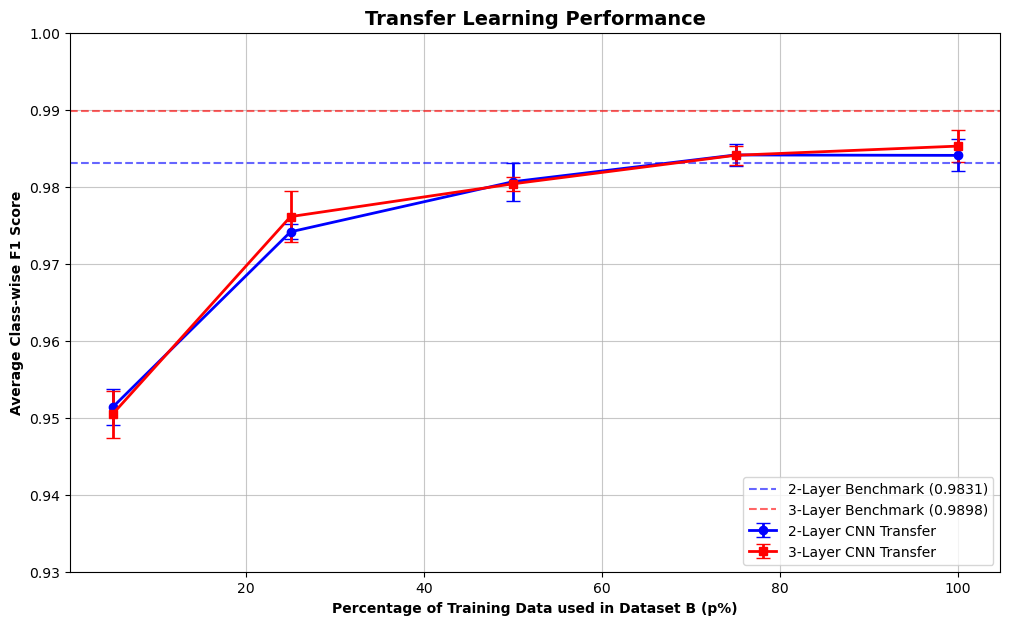

In [206]:
plt.figure(figsize=(12, 7))

# Plot the Transfer Learning results with Error Bars
plt.errorbar(p_values, m2_means, yerr=m2_stds, label='2-Layer CNN Transfer', 
             marker='o', linestyle='-', color='blue', capsize=5, linewidth=2)
plt.errorbar(p_values, m3_means, yerr=m3_stds, label='3-Layer CNN Transfer', 
            marker='s', linestyle='-', color='red', capsize=5, linewidth=2)

# 2. Plot the Benchmarks as straight horizontal lines
plt.axhline(y=benchmark2, color='blue', linestyle='--', alpha=0.6, 
            label=f'2-Layer Benchmark ({benchmark2:.4f})')
plt.axhline(y=benchmark3, color='red', linestyle='--', alpha=0.6, 
            label=f'3-Layer Benchmark ({benchmark3:.4f})')

# 3. Formatting (Per Rubric: "Easily Distinguishable")
plt.title('Transfer Learning Performance', 
          fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Training Data used in Dataset B (p%)', fontweight='bold')
plt.ylabel('Average Class-wise F1 Score', fontweight='bold')

# adjusting the Y-axis to be more expressive
plt.ylim(0.93, 1.0) 
plt.grid(True, linestyle='-', alpha=0.7)
plt.legend(loc='lower right')

plt.show()

In [207]:
print(f"{'p (%)':<2} | {'2-Layer Avg F1':<15} | {'3-Layer Avg F1':<15}")
print("-" * 45)
for i, p in enumerate(p_values):
    print(f"{p:<5} | {m2_means[i]:<15.4f} | {m3_means[i]:<15.4f}")

p (%) | 2-Layer Avg F1  | 3-Layer Avg F1 
---------------------------------------------
5     | 0.9514          | 0.9505         
25    | 0.9741          | 0.9761         
50    | 0.9807          | 0.9804         
75    | 0.9841          | 0.9841         
100   | 0.9841          | 0.9853         


# Interpretation of the Plot after experimenting Q3

- After attempting with completing Q3 and researhing for optimization for the two type CNNs. My results shows me that the features learned from digits 0–4 are highly effective for digits 5–9. I chosed to one small percentage of 5 and then increments of 25, up to 100% to see what would have it. I noticed that at 5% the f1-score already reached 98% for both CNNs and it as the p% increasing f1 score increases. Once it ran 100% it almost approach with the benchmark lines and converges at that line. 

### I enjoy doing Q3 alot and seeing how transfer learning with CNN work.